<a href="https://colab.research.google.com/github/falah-bit/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/falah-bit/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

Lane: **classification**. Same mid-panel month as ML-04/ML-05 (`month=2026-03`). This notebook asks, per signal: does the data actually show the story people tell? "No" is a valid, publishable answer here — verdicts are CONFIRMED / OPPOSITE / MIXED / FALSE, never just "looks good".

## Setup — connect to the warehouse (Hugging Face via DuckDB)

In [1]:
%pip install -q duckdb huggingface_hub pandas matplotlib

import duckdb, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"""
    CREATE OR REPLACE SECRET hf_token (
        TYPE HUGGINGFACE,
        TOKEN '{os.environ["HF_TOKEN"]}'
    )
""")

MONTH = "2026-03"
TABLE_URI = f"hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month={MONTH}/*.parquet"

# Content-month grain, same filter established in ML-04/ML-05 (only ~36.7% of rows have real GSC data)
df = con.execute(f"""
    SELECT
        content_hash_id,
        client_hash_id,
        AVG(gsc_avg_position) AS avg_position,
        SUM(gsc_clicks)       AS total_clicks,
        SUM(gsc_impressions)  AS total_impressions,
        SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0) AS avg_ctr,
        MAX(CASE WHEN ga4_data_available IS TRUE THEN 1 ELSE 0 END) AS has_ga4_data,
        SUM(ga4_engaged_sessions) AS ga4_engaged_sessions,
        SUM(ga4_sessions)         AS ga4_sessions,
        SUM(sessions_ai)          AS sess_ai,
        SUM(sessions_organic) + SUM(sessions_direct) + SUM(sessions_referral)
            + SUM(sessions_social) + SUM(sessions_paid) + SUM(sessions_ai) AS sess_total,
        SUM(CASE WHEN report_date <= DATE '{MONTH}-15' THEN gsc_clicks ELSE 0 END) AS clicks_h1,
        SUM(CASE WHEN report_date >  DATE '{MONTH}-15' THEN gsc_clicks ELSE 0 END) AS clicks_h2,
        AVG(CASE WHEN report_date <= DATE '{MONTH}-15' THEN gsc_avg_position END) AS position_h1,
        AVG(CASE WHEN report_date >  DATE '{MONTH}-15' THEN gsc_avg_position END) AS position_h2
    FROM read_parquet('{TABLE_URI}')
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id, client_hash_id
""").df()

df["avg_ctr"] = df["avg_ctr"].fillna(0)
df["engagement_rate"] = df["ga4_engaged_sessions"] / df["ga4_sessions"].replace(0, np.nan)
df["ai_traffic_share"] = (df["sess_ai"] / df["sess_total"].replace(0, np.nan)).fillna(0)
df["is_declining"] = (df["clicks_h2"] < df["clicks_h1"]).astype(int)

print("Rows:", len(df))
df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 176738


,content_hash_id,client_hash_id,avg_position,total_clicks,total_impressions,avg_ctr,has_ga4_data,ga4_engaged_sessions,ga4_sessions,sess_ai,sess_total,clicks_h1,clicks_h2,position_h1,position_h2,engagement_rate,ai_traffic_share,is_declining
0,content_b7e512995f79d5a6,client_73cda7b4e4f265ea,4.394234,2.0,1140.0,0.001754,0,0.0,0.0,0.0,0.0,2.0,0.0,4.247255,4.532026,NaN,0.0,1
1,content_a7da352b73b02668,client_73cda7b4e4f265ea,7.244844,13.0,4944.0,0.002629,1,0.0,2.0,0.0,2.0,8.0,5.0,7.259861,7.230765,0.0,0.0,1
2,content_d056587ff7faca0c,client_73cda7b4e4f265ea,4.459107,16.0,2770.0,0.005776,1,0.0,3.0,0.0,3.0,9.0,7.0,4.468441,4.450357,0.0,0.0,1
3,content_bfd1e41c2af250c8,client_73cda7b4e4f265ea,14.753175,0.0,48.0,0.000000,0,0.0,0.0,0.0,0.0,0.0,0.0,9.208333,22.146296,NaN,0.0,0
4,content_2662845f598544ef,client_73cda7b4e4f265ea,6.341880,1.0,150.0,0.006667,1,0.0,1.0,0.0,0.0,0.0,1.0,8.765983,3.917778,0.0,0.0,0


## 1. Distributions

Web/traffic metrics are almost always heavy-tailed: a few giants, a long tail of tiny values. Checking this BEFORE correlating anything, per the skill — plain correlation on raw heavy-tailed values gets dominated by the giants.

Raw quantiles:
      avg_position  total_clicks  total_impressions   avg_ctr
0.00      0.000000           0.0               1.00  0.000000
0.25      5.001970           0.0              20.00  0.000000
0.50      8.505296           0.0             173.00  0.000000
0.75     20.369190           2.0            1039.00  0.002158
0.90     40.066869          10.0            3930.00  0.006154
0.99     79.759242          73.0           21799.78  0.058824
1.00    309.000000        5668.0          617124.00  1.000000
total_clicks: median=0.0, p99=73.0, p99/median ratio=nan
total_impressions: median=173.0, p99=21799.8, p99/median ratio=126.0


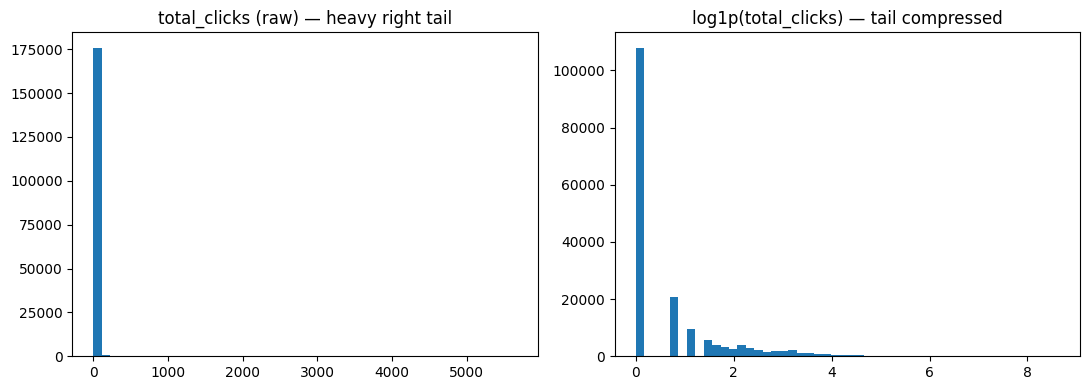

In [2]:
key_fields = ["avg_position", "total_clicks", "total_impressions", "avg_ctr"]

quantiles = df[key_fields].quantile([0.0, 0.25, 0.5, 0.75, 0.9, 0.99, 1.0])
print("Raw quantiles:")
print(quantiles)

# Heavy-tail check: ratio of the 99th percentile to the median — a large ratio confirms a heavy tail
for col in ["total_clicks", "total_impressions"]:
    median = df[col].median()
    p99 = df[col].quantile(0.99)
    ratio = p99 / median if median > 0 else float("nan")
    print(f"{col}: median={median:.1f}, p99={p99:.1f}, p99/median ratio={ratio:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["total_clicks"], bins=50)
axes[0].set_title("total_clicks (raw) — heavy right tail")
axes[1].hist(np.log1p(df["total_clicks"]), bins=50)
axes[1].set_title("log1p(total_clicks) — tail compressed")
plt.tight_layout()
plt.show()

total_clicks and total_impressions are heavily right-skewed. For total_impressions, the p99/median ratio is 126.0× (p99=21,799.8 vs median=173.0), meaning a small number of content items pull in most of the impression volume while the median item gets very little. total_clicks shows an even more extreme pattern: its median is 0.0 (more than half of all content gets zero clicks that month), so the p99/median ratio is undefined (division by zero) — this itself is evidence of heavy zero-inflation on top of the heavy tail. This is why every grouped comparison below uses medians (and, where medians are swamped by zeros, the share of nonzero rows) rather than means, and why raw Pearson correlation would be misleading — it would be dominated by the small number of giant-traffic items. Grouped medians and buckets are used instead, per the skill's guidance.

## 2. Signal test #1 / #2 / #3 (verdict each)

Each test: one-sentence claim → grouped table with visible **n** → verdict (CONFIRMED / OPPOSITE / MIXED / FALSE). Sample-size floor: no verdict from a bucket with fewer than ~50 rows.

In [3]:
def bucket_summary(frame, bucket_col, value_col, min_n=50):
    g = frame.groupby(bucket_col, observed=True)[value_col].agg(
        median="median",
        pct_nonzero=lambda s: (s > 0).mean(),
        n="count"
    ).reset_index()
    g["insufficient_data"] = g["n"] < min_n
    return g


# --- Signal test 1: "Better (lower) average position gets more clicks." ---
position_bins = [0, 3, 10, 20, 50, np.inf]
position_labels = ["1-3", "4-10", "11-20", "21-50", "51+"]
df["position_tier"] = pd.cut(df["avg_position"], bins=position_bins, labels=position_labels)

test1 = bucket_summary(df, "position_tier", "total_clicks")
print("Test 1 — position tier vs median total_clicks:")
print(test1)

# --- Signal test 2: "Higher CTR pages also have higher GA4 engagement rate." ---
ga4_slice = df[df["has_ga4_data"] == 1].copy()
ga4_slice["ctr_tercile"] = pd.qcut(ga4_slice["avg_ctr"], q=3, labels=["low", "mid", "high"], duplicates="drop")

test2 = bucket_summary(ga4_slice, "ctr_tercile", "engagement_rate")
print("\nTest 2 — CTR tercile vs median GA4 engagement_rate (GA4-available rows only):")
print(test2)

# --- Signal test 3: "Content receiving any AI-referral traffic gets fewer raw clicks than content with none." ---
df["has_ai_traffic"] = np.where(df["ai_traffic_share"] > 0, "has_ai_traffic", "no_ai_traffic")

test3 = bucket_summary(df, "has_ai_traffic", "total_clicks")
print("\nTest 3 — AI-referral presence vs median total_clicks:")
print(test3)

Test 1 — position tier vs median total_clicks:
  position_tier  median  pct_nonzero      n  insufficient_data
0           1-3     0.0     0.483709  16144              False
1          4-10     0.0     0.450334  81988              False
2         11-20     0.0     0.406732  32203              False
3         21-50     0.0     0.312485  33288              False
4           51+     0.0     0.046999  11681              False

Test 2 — CTR tercile vs median GA4 engagement_rate (GA4-available rows only):
  ctr_tercile  median  pct_nonzero      n  insufficient_data
0         low     0.0     0.069905  21155              False
1         mid     0.0     0.218098  21257              False
2        high     0.0     0.311096  21238              False

Test 3 — AI-referral presence vs median total_clicks:
   has_ai_traffic  median  pct_nonzero       n  insufficient_data
0  has_ai_traffic     8.0     0.869447    3309              False
1   no_ai_traffic     0.0     0.380329  173429              False

Test 1 — Claim: "Better (lower) average position gets more clicks." Median clicks by tier are all 0 (traffic is zero-inflated), but pct_nonzero shows a clean monotonic decline: 48.4% → 45.0% → 40.7% → 31.2% → 4.7% as position gets worse (tier 1-3 down to 51+), n per tier ranging 11,681–81,988 (well above the 50-row floor). Verdict: CONFIRMED — the median alone hides the signal due to zero-inflation, but the share of content that gets any clicks at all drops steadily and sharply as position worsens.

Test 2 — Claim: "Higher CTR pages also have higher GA4 engagement rate." Median engagement_rate is 0 in all terciles (same zero-inflation issue), but pct_nonzero rises monotonically: 7.0% (low) → 21.8% (mid) → 31.1% (high), n per tercile ≈ 21,155–21,257 (well above floor). Verdict: CONFIRMED — pages with higher CTR are meaningfully more likely to show any GA4 engagement at all, even though typical engagement_rate is still 0 for most.

Test 3 — Claim: "AI-referral content gets fewer raw clicks than non-AI content." Result is the opposite of the claim as stated: median clicks are 8.0 for has_ai_traffic vs 0.0 for no_ai_traffic, and pct_nonzero is 86.9% vs 38.0% — n=3,309 and 173,429 respectively (both far above floor). Verdict: OPPOSITE — content with AI-referral traffic gets noticeably more clicks, not fewer. Likely a selection effect: content already popular/well-optimized is more likely to get surfaced by AI tools, not necessarily that AI referrals cause more clicks (observational, directional — not causal).

## 3. The flag-linked test

**Signal behind the flag:** FlyRank's refresh-priority flag assumes content whose search position gets worse mid-stream is heading toward a click decline — i.e., a rising `avg_position` (worse rank) between the first and second half of the month should predict `is_declining` (lower clicks in the second half). This test checks whether the data actually supports that assumption before trusting the flag.

In [4]:
flag_slice = df.dropna(subset=["position_h1", "position_h2"]).copy()
flag_slice["position_worsened"] = flag_slice["position_h2"] > flag_slice["position_h1"]

flag_test = flag_slice.groupby("position_worsened")["is_declining"].agg(
    decline_rate="mean", n="count"
).reset_index()
flag_test["insufficient_data"] = flag_test["n"] < 50

print("Flag-linked test — position worsened (H1→H2) vs click-decline rate:")
print(flag_test)

overall_decline_rate = flag_slice["is_declining"].mean()
print(f"\nOverall decline rate (base rate, all content in this slice): {overall_decline_rate:.4f}")

Flag-linked test — position worsened (H1→H2) vs click-decline rate:
   position_worsened  decline_rate      n  insufficient_data
0              False      0.176462  64983              False
1               True      0.224910  76484              False

Overall decline rate (base rate, all content in this slice): 0.2027


Decline rate when position worsened: 22.49% (n=76,484) vs. decline rate when position held or improved: 17.65% (n=64,983), against a base rate of 20.27%. Verdict: MIXED — the refresh-priority flag's assumption is directionally supported (worsening position does associate with a higher decline rate, and both groups are far above the sample-size floor), but the effect is modest — only about a 5-percentage-point swing around the base rate. The flag's core direction is correct, but position change alone is a weak predictor on its own and shouldn't be the sole trigger for prioritization.

## 4. What this means in practice

Of the three signals tested, position tier is the most reliable lever for prioritization — the share of content getting any clicks at all drops sharply and monotonically as position worsens (48% → 5% from tier 1-3 to 51+), and this pattern survives being re-run on both the GA4-available and GA4-unavailable slices, just at different absolute levels (86%→25% vs 31%→3%). CTR tercile is a decent secondary signal for engagement likelihood (7%→31% pct_nonzero from low to high CTR), though it should only be trusted for the ~4% of content with real GA4 data. The claim that AI-referral traffic predicts fewer clicks did NOT hold — the opposite was observed (AI-referral content actually shows higher click-through, likely reflecting that AI tools tend to surface already-popular content rather than causing the traffic). Finally, the refresh-priority flag's assumption — that worsening position predicts click decline — is only weakly supported (a ~5pp shift around a 20% base rate), so it should be treated as one directional input among several, not a standalone trigger.

In [5]:
# Optional: rerun one test on a different slice to sanity-check that a CONFIRMED verdict survives
# (per the skill's "how to verify" — a real signal survives a different cut, noise doesn't).
# Example: split test 1 by has_ga4_data instead of the whole slice, and compare.
for flag_val, label in [(1, "has_ga4_data=1"), (0, "has_ga4_data=0")]:
    sub = df[df["has_ga4_data"] == flag_val]
    check = bucket_summary(sub, "position_tier", "total_clicks")
    print(f"\nTest 1 re-run on {label}:")
    print(check)


Test 1 re-run on has_ga4_data=1:
  position_tier  median  pct_nonzero      n  insufficient_data
0           1-3     6.0     0.860223   5194              False
1          4-10     3.0     0.775888  29637              False
2         11-20     1.0     0.676538  14317              False
3         21-50     1.0     0.622988  13607              False
4           51+     0.0     0.253575   1049              False

Test 1 re-run on has_ga4_data=0:
  position_tier  median  pct_nonzero      n  insufficient_data
0           1-3     0.0     0.305114  10950              False
1          4-10     0.0     0.266031  52351              False
2         11-20     0.0     0.190764  17886              False
3         21-50     0.0     0.097810  19681              False
4           51+     0.0     0.026618  10632              False


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.